# Clustering Analysis on the Iris Dataset

This notebook demonstrates unsupervised learning using the K-Means clustering algorithm on the Iris dataset. The workflow includes exploratory data analysis, determination of the optimal number of clusters using the Elbow Method, clustering on petal and sepal features, and visualization of the resulting clusters.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Load the dataset
# Note: This code assumes 'iris.csv' is in the same directory.
df = pd.read_csv('iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Explore the Distribution of Features

C:\Users\Praneeth\AppData\Local\Temp\ipykernel_18436\3962611078.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x], bins=20)
C:\Users\Praneeth\AppData\Local\Temp\ipykernel_18436\3962611078.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x], bins=20)
C:\Users\Praneeth\AppData\Local\

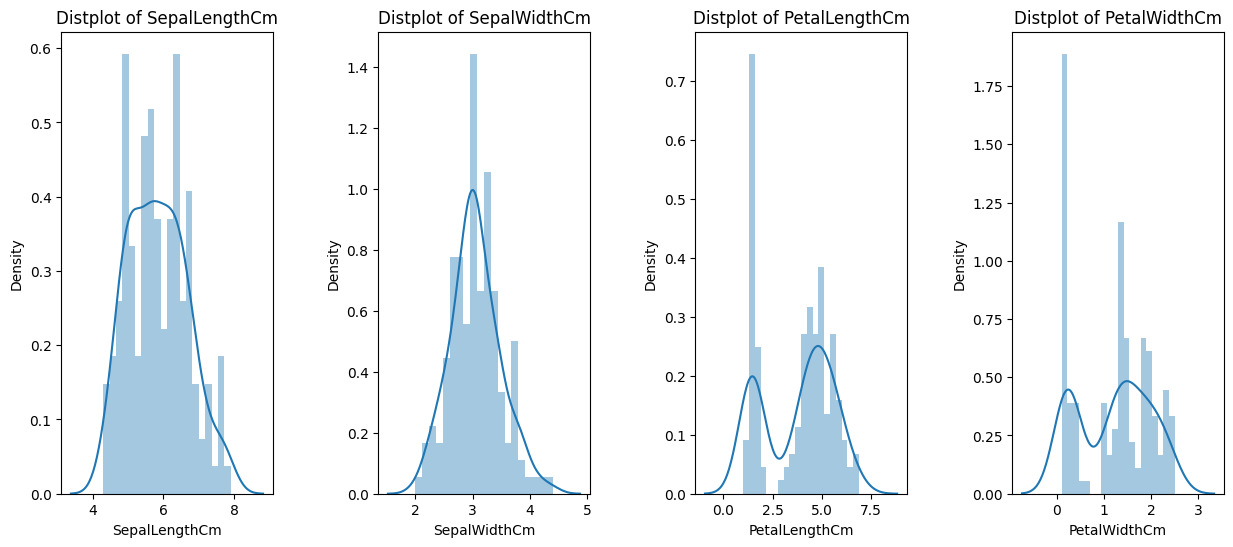

In [2]:
# 2. Distribution Plots for the numerical features in the Iris dataset
plt.figure(1, figsize=(15, 6))
n = 0
for x in ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']:
    n += 1
    plt.subplot(1, 4, n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(df[x], bins=20)
    plt.title('Distplot of {}'.format(x))
plt.show()

## 3. Pairwise Feature Relationships

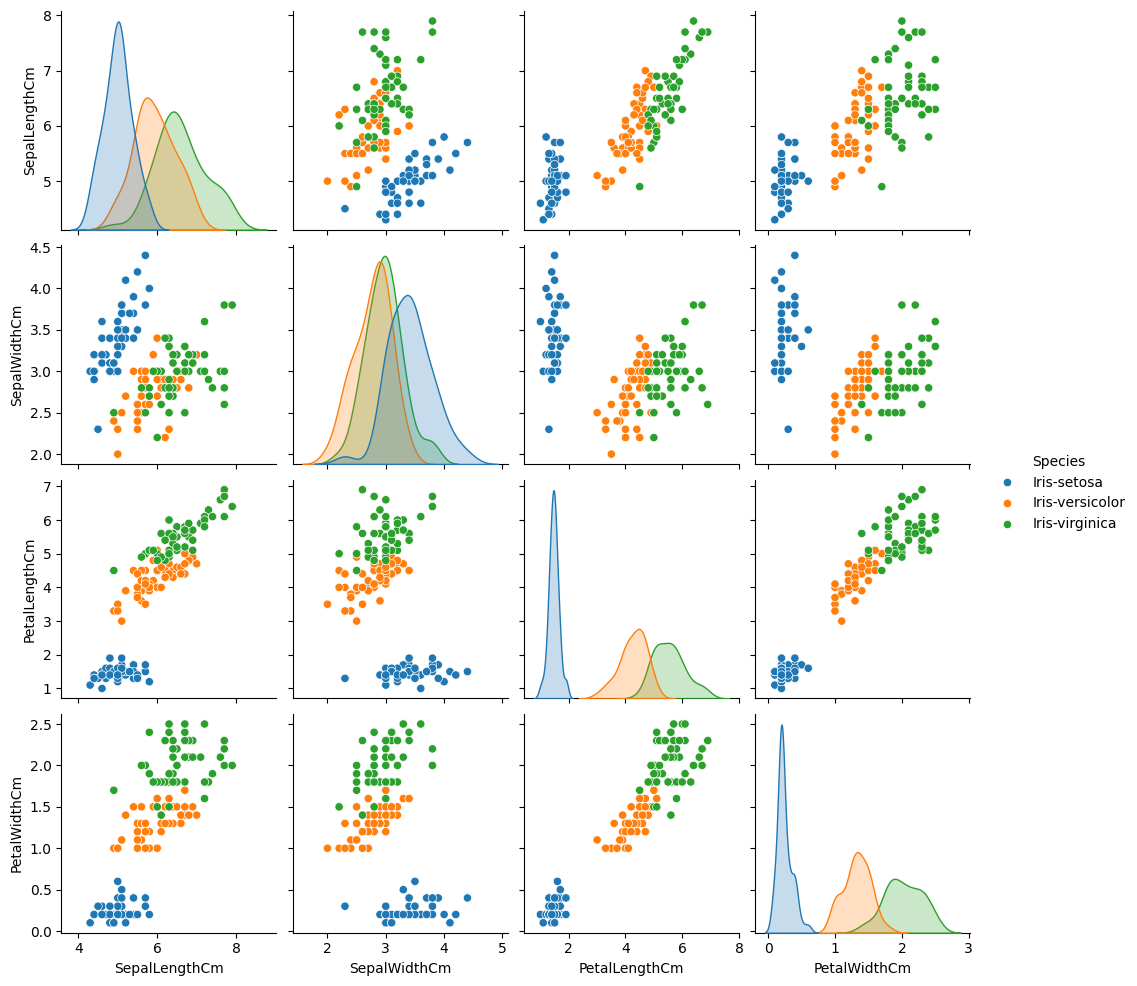

In [3]:
# 3. Pair Plot, using 'Species' as the hue
# We drop 'Id' as it's not needed for the pair plot
sns.pairplot(df.drop('Id', axis=1), vars=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], hue="Species")
plt.show()

## 4. Petal Feature Clustering

The petal length and petal width features are used to determine an appropriate number of clusters and visualize the resulting segmentation.

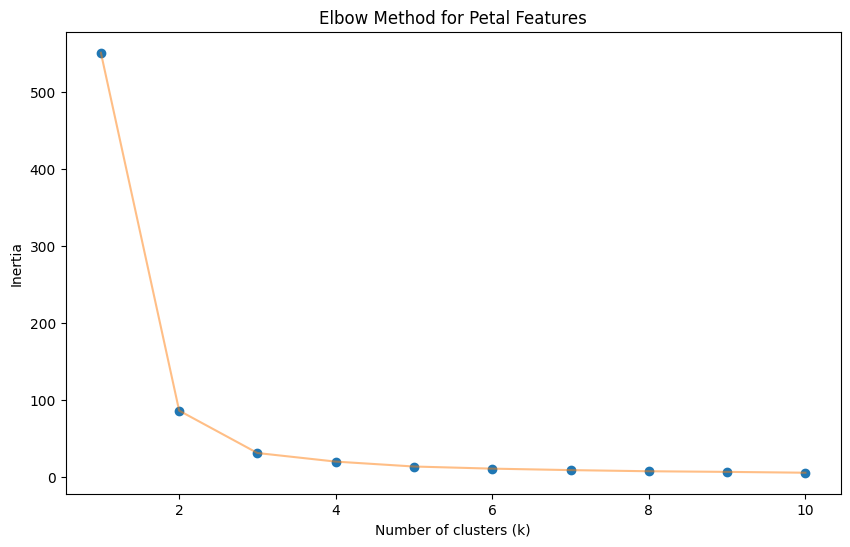

In [4]:
# --- Part 1: Analysis on Petal Features --- 

# 4. Create a feature set and run the Elbow Method for Petal data
X_petal = df[['PetalLengthCm', 'PetalWidthCm']].iloc[:, :].values
inertia_petal = []
for n in range(1, 11):
    kmeans_petal = KMeans(n_clusters=n, init='k-means++', random_state=111, n_init='auto')
    kmeans_petal.fit(X_petal)
    inertia_petal.append(kmeans_petal.inertia_)

# 5. Plot the Elbow Method results for Petal data
plt.figure(1, figsize=(10, 6))
plt.plot(np.arange(1, 11), inertia_petal, 'o')
plt.plot(np.arange(1, 11), inertia_petal, '-', alpha=0.5)
plt.title('Elbow Method for Petal Features')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

## 5. Sepal Feature Clustering

The same analysis is repeated using sepal length and sepal width to compare clustering behaviour.

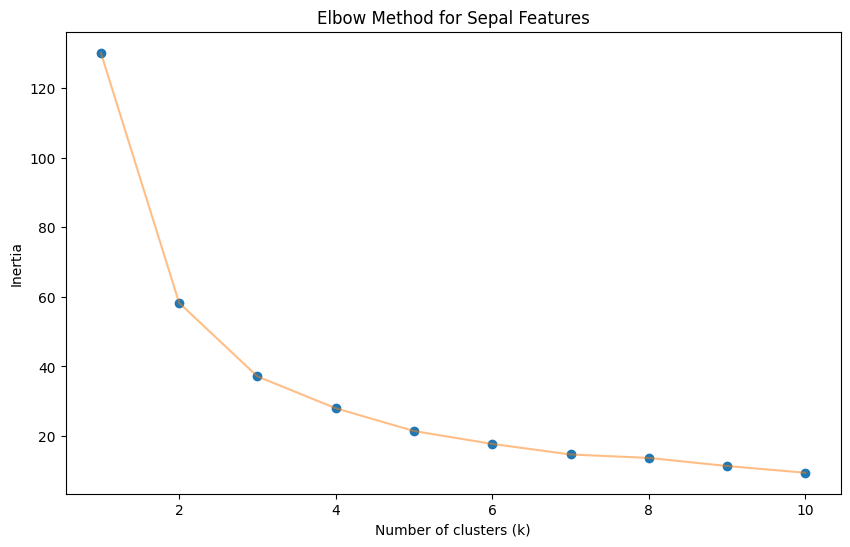

In [5]:
# --- Part 2: Analysis on Sepal Features ---

# 6. Create a feature set and run the Elbow Method for Sepal data
X_sepal = df[['SepalLengthCm', 'SepalWidthCm']].iloc[:, :].values
inertia_sepal = []
for n in range(1, 11):
    kmeans_sepal = KMeans(n_clusters=n, init='k-means++', random_state=111, n_init='auto')
    kmeans_sepal.fit(X_sepal)
    inertia_sepal.append(kmeans_sepal.inertia_)

# 7. Plot the Elbow Method results for Sepal data
plt.figure(1, figsize=(10, 6))
plt.plot(np.arange(1, 11), inertia_sepal, 'o')
plt.plot(np.arange(1, 11), inertia_sepal, '-', alpha=0.5)
plt.title('Elbow Method for Sepal Features')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

## 6. Visualize Sepal Clusters

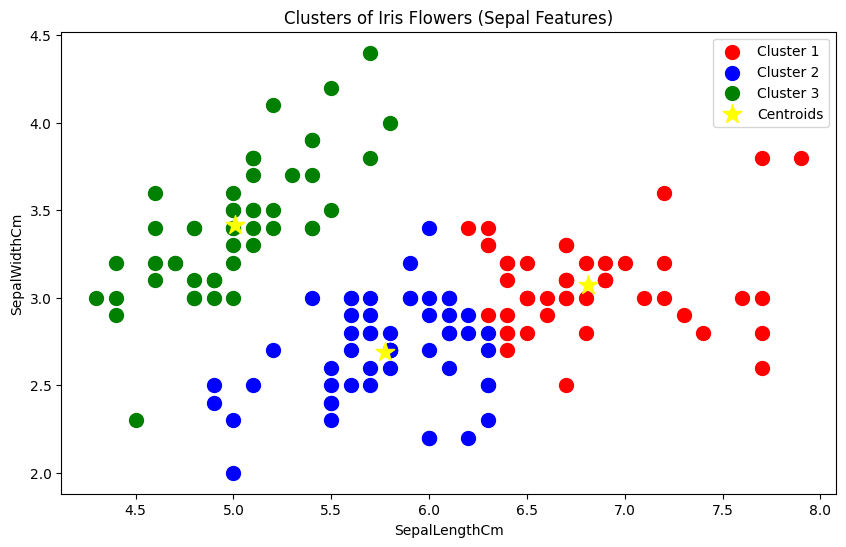

In [6]:
# 8. Fit the K-Means model and visualize the clusters for Sepal data
# Based on the elbow plot, k=3 is a reasonable choice.
kmeans_sepal_final = KMeans(n_clusters=3, init='k-means++', random_state=111, n_init='auto')
y_kmeans_sepal = kmeans_sepal_final.fit_predict(X_sepal)

# 9. Plot the final clusters and their centroids for Sepal data
plt.figure(1, figsize=(10, 6))
plt.scatter(X_sepal[y_kmeans_sepal == 0, 0], X_sepal[y_kmeans_sepal == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X_sepal[y_kmeans_sepal == 1, 0], X_sepal[y_kmeans_sepal == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X_sepal[y_kmeans_sepal == 2, 0], X_sepal[y_kmeans_sepal == 2, 1], s=100, c='green', label='Cluster 3')

# Plot the centroids
plt.scatter(kmeans_sepal_final.cluster_centers_[:, 0], kmeans_sepal_final.cluster_centers_[:, 1], s=200, c='yellow', label='Centroids', marker='*')

plt.title('Clusters of Iris Flowers (Sepal Features)')
plt.xlabel('SepalLengthCm')
plt.ylabel('SepalWidthCm')
plt.legend()
plt.show()

## Conclusion

K-Means clustering was applied separately to petal and sepal measurements from the Iris dataset. The results demonstrate how different feature selections influence cluster separation, with petal features generally providing more distinct clusters than sepal features.